In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("start.csv", delimiter=";")
df["TIMESTAMP"] -= df["TIMESTAMP"][0]
df["TIMESTAMP"] /= 1000
df["TANK_PRESS"] /= 100
df["TANK_D_PRESS"] /= 100
df["TANK_D_PRESS"] = df["TANK_D_PRESS"].rolling(20).mean()
df["TANK_PRESS"] = df["TANK_PRESS"].rolling(20).mean()

df = df[df["TIMESTAMP"] > 81]
df["TIMESTAMP"] -= 81
df.head()

,TIMESTAMP,TEMP1,TEMP2,TEMP3,TANK_PRESS,TANK_D_PRESS,CPU_USAGE,MEM_USAGE,DISK_UTILIZATION,TENSO
13894,0.004,0,0,0,56.0375,0.9795,100.0,8.45,64.93,1.47
13895,0.009,0,0,0,56.0440,1.0065,100.0,8.45,64.93,1.47
13896,0.015,0,0,0,56.0505,0.9965,100.0,8.45,64.93,1.70
13897,0.021,0,0,0,56.0570,0.9865,100.0,8.45,64.93,1.70
13898,0.027,0,0,0,56.0705,0.9765,100.0,8.45,64.93,2.06


# Ogólny wykres ciągu w teście

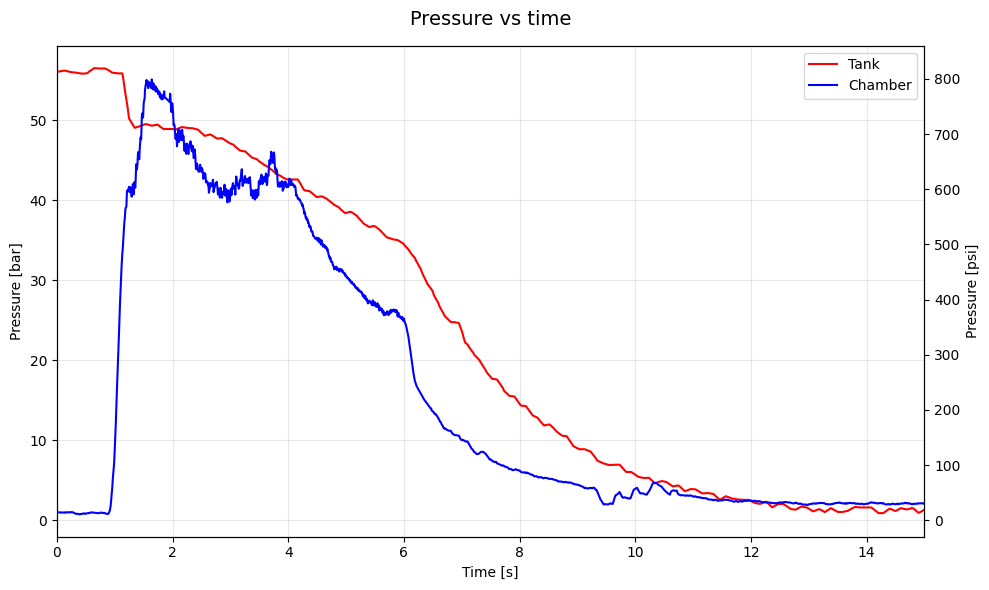

In [3]:
import matplotlib.pyplot as plt

# Współczynnik konwersji: 1 bar = 14.5038 psi
BAR_TO_PSI = 14.5038

fig, ax1 = plt.subplots(figsize=(10, 6))


# Plotowanie danych na pierwszej osi (lewa - bar)
line1, = ax1.plot(df["TIMESTAMP"], df["TANK_PRESS"], label="Tank", color='r', linewidth=1.5)
line2, = ax1.plot(df["TIMESTAMP"], df["TANK_D_PRESS"], label="Chamber", color='b', linewidth=1.5)

# Konfiguracja lewej osi Y i osi X
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Pressure [bar]")
ax1.set_xlim(0, 15) # Zakres w sekundach: 81s - 95s
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

y_min, y_max = ax1.get_ylim()
ax2.set_ylim(y_min * BAR_TO_PSI, y_max * BAR_TO_PSI)
ax2.set_ylabel("Pressure [psi]")

# Tytuł wykresu
plt.title("Pressure vs time", pad=15, fontsize=14)

# Legenda (zbieramy etykiety z obu linii narysowanych na ax1)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("../../charts/static_12_03_2026.png", dpi=400)
plt.show()

# Przybliżenie na oscylacje

In [ ]:
df2 = pd.read_csv("start.csv", delimiter=";")
df2["TIMESTAMP"] -= df2["TIMESTAMP"][0]
df2["TANK_PRESS"] /= 100
df2["TANK_D_PRESS"] /= 100
df2.head()

,TIMESTAMP,TEMP1,TEMP2,TEMP3,TANK_PRESS,TANK_D_PRESS,CPU_USAGE,MEM_USAGE,DISK_UTILIZATION,TENSO
0,0,0,0,0,56.44,1.08,100.0,8.44,65.94,1.44
1,6,0,0,0,55.80,1.22,100.0,8.44,65.94,1.47
2,11,0,0,0,55.80,1.22,100.0,8.44,65.94,1.47
3,17,0,0,0,55.80,1.19,100.0,8.44,65.94,2.09
4,23,0,0,0,55.80,1.19,100.0,8.44,65.94,1.59


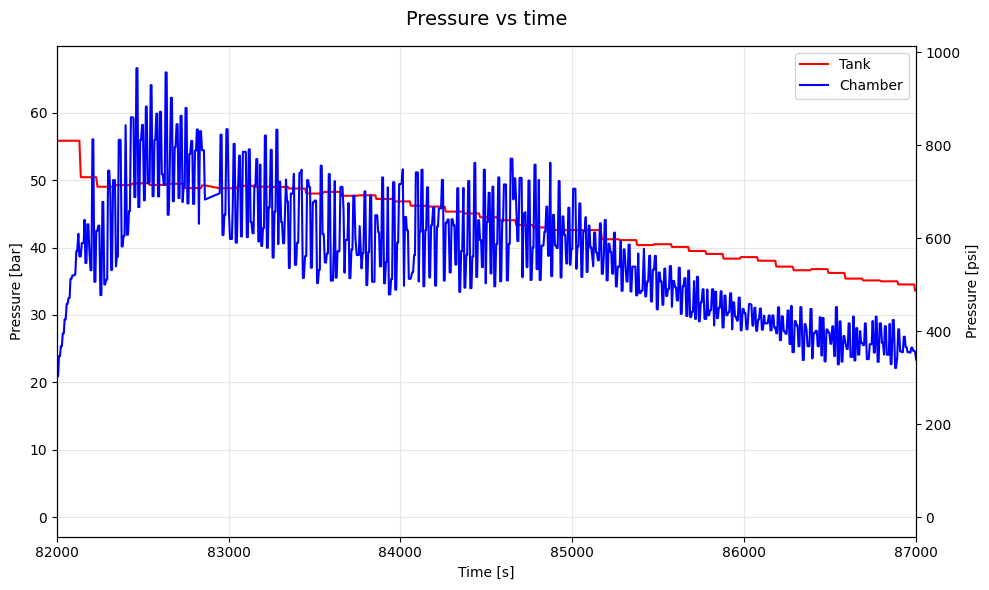

In [ ]:
import matplotlib.pyplot as plt

# Współczynnik konwersji: 1 bar = 14.5038 psi
BAR_TO_PSI = 14.5038

fig, ax1 = plt.subplots(figsize=(10, 6))


# Plotowanie danych na pierwszej osi (lewa - bar)
line1, = ax1.plot(df2["TIMESTAMP"], df2["TANK_PRESS"], label="Tank", color='r', linewidth=1.5)
line2, = ax1.plot(df2["TIMESTAMP"], df2["TANK_D_PRESS"], label="Chamber", color='b', linewidth=1.5)

# Konfiguracja lewej osi Y i osi X
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Pressure [bar]")
ax1.set_xlim(82000, 87000) # Zakres w sekundach: 81s - 95s
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

y_min, y_max = ax1.get_ylim()
ax2.set_ylim(y_min * BAR_TO_PSI, y_max * BAR_TO_PSI)
ax2.set_ylabel("Pressure [psi]")

# Tytuł wykresu
plt.title("Pressure vs time", pad=15, fontsize=14)

# Legenda (zbieramy etykiety z obu linii narysowanych na ax1)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("../../charts/zoom_static_12_03_2026.png")
plt.show()